# Lista de Exercício 5
### Introdução à Visão Computacional (SEL0339/SEL5886)

**Instruções:**

 1. Esta lista consiste de 4 exercícios.
 1. Deve-se colocar comentários nos códigos desenvolvidos.
 1. As perguntas devem ser respondidas também como comentários no arquivo.
 1. Colocar seu nome e número USP abaixo.
 1. Quaisquer problemas na execução das listas, entrar em contato com os monitores.
 1. Depois de terminado os exercícios, deve ser gerado um arquivo **extensão .ipynb** para ser enviado ao professor pelo E-DISCIPLINAS da disciplina até a data máxima de entrega.
 1. Caso não seja enviado, o aluno ficará sem nota.


---


 <table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/LAVI-USP/SEL0339-SEL5886_2024/blob/main/praticas/Lista_de_Exercicio_5.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Executar no Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/LAVI-USP/SEL0339-SEL5886_2024/blob/main/praticas/Lista_de_Exercicio_5.ipynb"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />Ver codigo fonte no GitHub</a>
  </td>
</table>

`Nome: Marcus Vinícius Costa Reis`

`Número USP: 12549384`

### Introdução:


Nesta lista iremos abordar os tópicos de Classificação de Padrões em Imagens, desde o pré-processamento e tratamento das variaves até a implementação de classificadores.

Vamos utilizar dois conjunto de dados, ambos estão disponíveis em [UC Irvine Machine Learning Repository](https://archive.ics.uci.edu/), pode baixar diretamente e carregar o conjunto de dados ou simplesmente instalar a biblioteca abaixo e importar.

```
!pip install ucimlrepo
```


## Iris dataset
O conjunto de dados contém 3 classes, cada uma com 50 instâncias, onde cada classe se refere a um tipo de planta do gênero Iris.

![](https://s3.amazonaws.com/assets.datacamp.com/blog_assets/Machine+Learning+R/iris-machinelearning.png)

E o conjunto de dados
| Nome da Variável | Papel    | Tipo         | Descrição                                          | Unidades | Valores Ausentes |
|------------------|----------|--------------|----------------------------------------------------|----------|------------------|
| sepal length     | Atributo | Contínuo     | Comprimento da sépala                              | cm       | não              |
| sepal width      | Atributo | Contínuo     | Largura da sépala                                  | cm       | não              |
| petal length     | Atributo | Contínuo     | Comprimento da pétala                              | cm       | não              |
| petal width      | Atributo | Contínuo     | Largura da pétala                                  | cm       | não              |
| class            | Variável resposta     | Categórico   | Classe da planta Iris: Iris Setosa, Iris Versicolour ou Iris Virginica | -        | não              |


Para carregar o conjunto de dados

In [46]:
!pip install ucimlrepo

In [47]:
from ucimlrepo import fetch_ucirepo

# Importando outras bibliotecas que serão utilizadas
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram

# carregando o conjunto de dados
iris = fetch_ucirepo(id=53)

# atributos
X_iris = iris.data.features
# variavel resposta
y_iris = iris.data.targets

print(X_iris)

     sepal length  sepal width  petal length  petal width
0             5.1          3.5           1.4          0.2
1             4.9          3.0           1.4          0.2
2             4.7          3.2           1.3          0.2
3             4.6          3.1           1.5          0.2
4             5.0          3.6           1.4          0.2
..            ...          ...           ...          ...
145           6.7          3.0           5.2          2.3
146           6.3          2.5           5.0          1.9
147           6.5          3.0           5.2          2.0
148           6.2          3.4           5.4          2.3
149           5.9          3.0           5.1          1.8

[150 rows x 4 columns]


## Doenças Cardiacas (Heart Disease)
Este conjunto de dados representa a condição de presença de doença cardiáca ou não no paciente
| Nome da Variável | Papel    | Tipo          | Descrição                                                  | Unidades | Valores Ausentes |
|------------------|----------|--------------|------------------------------------------------------------|----------|------------------|
| age              | Atributo | Inteiro             |      Anos                                                     | anos     | não              |
| sex              | Atributo | Categórico          |          Sexo                                                 | -        | não              |
| cp               | Atributo | Categórico                |       Tipo de dor no peito (4 tipo de valores)                                                   | -        | não              |
| trestbps         | Atributo | Inteiro                   | Pressão arterial em repouso (na admissão hospitalar)      | mm Hg    | não              |
| chol             | Atributo | Inteiro                   | Colesterol sérico                                         | mg/dl    | não              |
| fbs              | Atributo | Categórico                | Açúcar no sangue em jejum > 120 mg/dl                     | -        | não              |
| restecg          | Atributo | Categórico               |  resultados do eletrocardiograma em repouso (valores 0, 1, 2)                                                         | -        | não              |
| thalach          | Atributo | Inteiro                  | Frequência cardíaca máxima alcançada                      | -        | não              |
| exang            | Atributo | Categórico               | Angina induzida por exercício                             | -        | não              |
| oldpeak          | Atributo | Inteiro                   | Depressão do segmento ST induzida por exercício em repouso | -        | não              |
| slope            | Atributo | Categórico               | a inclinação do segmento ST no pico do exercício                                                          | -        | não              |
| ca               | Atributo | Inteiro                  | Número de vasos principais (0-3) coloridos por fluoroscopia | -        | sim              |
| thal             | Atributo | Categórico               |   thal: 0 = normal; 1 = defeito fixo; 2 = defeito reversível                                                        | -        | sim              |
| num              | Variável resposta     | Inteiro                  | Diagnóstico de doença cardíaca                            | -        | não              |


In [48]:
from ucimlrepo import fetch_ucirepo

heart_disease = fetch_ucirepo(id=45)

# carregando os dados
X_heart = heart_disease.data.features
y_heart = heart_disease.data.targets

print(X_heart)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   1       145   233    1        2      150      0      2.3   
1     67    1   4       160   286    0        2      108      1      1.5   
2     67    1   4       120   229    0        2      129      1      2.6   
3     37    1   3       130   250    0        0      187      0      3.5   
4     41    0   2       130   204    0        2      172      0      1.4   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   45    1   1       110   264    0        0      132      0      1.2   
299   68    1   4       144   193    1        0      141      0      3.4   
300   57    1   4       130   131    0        0      115      1      1.2   
301   57    0   2       130   236    0        2      174      0      0.0   
302   38    1   3       138   175    0        0      173      0      0.0   

     slope   ca  thal  
0        3  0.0   6.0  
1        2  3.0   3.0  
2        2  2.0

# 1) Ajuste de valores nos atributos e variável resposta
Nota: 1.5

1) Em ambos os conjunto de dados realize os tratamentos para transformar as variáveis em números. Tanto nas features X quanto na variável reposta y. Com base nas aulas utilize os Encoding que achar necessário e **justifique a escolha desse Enconding para cada variável (Label, One-hot, Ordinal) com códigos bem comentados**

Podem utilizar as funções implementadas no sklearn/pandas, consulte as documentações para qualquer dúvida do uso.

In [49]:
# label encoding
from sklearn.preprocessing import LabelEncoder

# One Hot
# no pandas tambem tem uma funcao implementada
# pandas.get_dummies
from sklearn.preprocessing import OneHotEncoder

# Ordinal Encoding
from sklearn.preprocessing import OrdinalEncoder

In [50]:
## -- Seu código começa AQUI -- ##

# --------------------------- Tratamento dos dados para o conjunto Iris dataset

# Ajustando os valores da variável resposta y_iris por meio da aplicação do
# One-Hot Encoding com pd.get_dummies
y_iris_encoded = pd.get_dummies(y_iris)

# --------------------------- Tratamento dos dados para o conjunto Heart Disease

# Como pode ser verificado no print realizado no trecho de código que importa os
# dados Heart Disease, as variáveis já estão transformadas em números.
# Para que a resolução não fique em branco, realiza-se o código comentado abaixo como se
# os atributos estivessem ainda na forma categórica:

# Primeiro, é importante separar quais atributos são ordinais ou nominais:

# Segundo as informações do site UC Irvine, tem-se:

# [NOMINAL - BINÁRIO] sex: 1 = male, 0 = female
# [NOMINAL]           cp: 1 = typical angina, 2 = atypical angina, 3 = non-anginal pain, 4 = asymptomatic
# [NOMINAL - BINÁRIO] fbs: true or false
# [NOMINAL]           restecg: values 0, 1 e 2
# [NOMINAL - BINÁRIO] exang: true or false
# [NOMINAL]           slope: 1. Upsloping, 2. Flat, 3. Downsloping
# [NOMINAL]           thal: values 0, 1 e 2

# Logo, os métodos apropriados para ajustar os valores de cada atributo seriam:

# sex -> LabelEncoding
# cp -> One-Hot Encoding
# fbs -> LabelEncoding
# restecg -> One-Hot Encoding
# exang -> LabelEncoding
# slope -> One-Hot Encoding
# thal -> One-Hot Encoding

# Assim, utilizando os métodos LabelEncoding e One-Hot Encoding, ficaria:

# label = LabelEncoder()  # Instanciando um objeto do LabelEncoder
# for col in ['sex', 'fbs', 'exang']:
#   X_heart[col] = label.fit_transform(X_heart[col])

# X_heart_enc = pd.get_dummies(X_heart, columns=['cp', 'restecg', 'slope', 'thal'])

## -- Seu código termina AQUI -- ##

## -- COMENTÁRIOS -- ##

# Para o caso da variável resposta y_iris, utilizou-se o One-Hot Encoding por se
# tratar de valores nominais que não apresentam apenas dois valores (são 3 classes).

# 2) Ajuste de valores nos atributos (Pré processamento)
Nota: 1.5

1)Implemente as suas funções para fazer os ajustes dos valores, utilizar apenas funções básicas do numpy ( max, min, mean, std, etc).
Escolha apenas **uma** para a implementação

Normalização
\begin{equation}
  X_{norm} = \frac{X - X_{min}}{X_{max}-X_{min}}
\end{equation}

onde $X$ representa o atributo analisado, $X_{max}$ e $X_{min}$ os valores máximos e mínimos daquele atributo

Z-score padronização
\begin{equation}
  Z = \frac{X - \bar{X}}{\sigma_{X}}
\end{equation}

onde $X$ representa o atributo analisado, $\bar{X}$ o seu valor médio e $\sigma_{X}$ o sue desvio padrão.

2) Utilize as funções implementadas no sklearn e faça o pré-processamento novamente, houve diferenças com a sua função implementada? Se sim, explique a diferença.

Também implemente o RobustScaler, apenas para olhar os valores entre os 3 metodos de feature scaling.

Obs: olhem sempre a documentação no sklearn dessas implementações para ver como implementar.

In [51]:
## -- Seu código começa AQUI -- ##

# Método escolhido - NORMALIZAÇÃO

def normaliza(X):
  # Realizando uma cópia do dataframe X
  X_norm = X.copy()

  # Obtendo os nomes das colunas para iterar cada coluna posteriormente
  col_names = X.columns

  # Aplicando a normalização à cada coluna de X_norm
  for col in col_names:
    X_norm[col] = (X[col] - np.min(X[col])) / (np.max(X[col]) - np.min(X[col]))

  return X_norm

# Aplicando a normalização aos valores de atributos de cada dataset
X_iris_norm = normaliza(X_iris)    # Normalizando X_iris
X_heart_norm = normaliza(X_heart)  # Normalizando X_heart

# Visualizando os resultados da função 'normaliza'
print(f'Valores normalizados de X_iris: \n{X_iris_norm}')
print(f'Valores normalizados de X_heart: \n{X_heart_norm}')


## -- Seu código termina AQUI -- ##

## -- COMENTÁRIOS -- ##

Valores normalizados de X_iris: 
     sepal length  sepal width  petal length  petal width
0        0.222222     0.625000      0.067797     0.041667
1        0.166667     0.416667      0.067797     0.041667
2        0.111111     0.500000      0.050847     0.041667
3        0.083333     0.458333      0.084746     0.041667
4        0.194444     0.666667      0.067797     0.041667
..            ...          ...           ...          ...
145      0.666667     0.416667      0.711864     0.916667
146      0.555556     0.208333      0.677966     0.750000
147      0.611111     0.416667      0.711864     0.791667
148      0.527778     0.583333      0.745763     0.916667
149      0.444444     0.416667      0.694915     0.708333

[150 rows x 4 columns]
Valores normalizados de X_heart: 
          age  sex        cp  trestbps      chol  fbs  restecg   thalach  \
0    0.708333  1.0  0.000000  0.481132  0.244292  1.0      1.0  0.603053   
1    0.791667  1.0  1.000000  0.622642  0.365297  0.0      1.

In [52]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

In [53]:
## -- Seu código começa AQUI -- ##

# Aplicando a função do sklearn para normalização, nesse caso a MinMaxScaler
mm_scaler = MinMaxScaler()  # Instanciando um objeto do MinMaxScaler

X_iris_sknorm = mm_scaler.fit_transform(X_iris)  # Normalizando X_iris
X_heart_sknorm = mm_scaler.fit_transform(X_heart)  # Normalizando X_heart

# Visualizando os resultados do MinMaxScaler
print('Valores normalizados utilizando MinMaxScaler \n\n')
print(f'Valores normalizados de X_iris: \n{X_iris_sknorm[:5,]}\n')
print(f'Valores normalizados de X_heart: \n{X_heart_sknorm}\n')

# Como é possível perceber, os resultados obtidos com a função implementada no
# trecho de código anterior e os obtidos com o método MinMaxScaler foram equivalentes
# em termos numéricos. No entanto, o tipo de retorno é distinto: a função 'normaliza'
# retorna um dataframe, enquanto MinMaxScaler retorna um ndarray

# Implementando o RobustScaler

r_scaler = RobustScaler()  # Instanciando um objeto do RobustScaler

X_iris_rnorm = r_scaler.fit_transform(X_iris)  # Normalizando X_iris
X_heart_rnorm = r_scaler.fit_transform(X_heart)  # Normalizando X_heart

# Visualizando os resultados do RobustScaler
print('\nValores normalizados utilizando RobustScaler \n\n')
print(f'Valores normalizados de X_iris: \n{X_iris_rnorm[:5,]}\n')
print(f'Valores normalizados de X_heart: \n{X_heart_rnorm}')

## -- Seu código termina AQUI -- ##

## -- COMENTÁRIOS -- ##

Valores normalizados utilizando MinMaxScaler 


Valores normalizados de X_iris: 
[[0.22222222 0.625      0.06779661 0.04166667]
 [0.16666667 0.41666667 0.06779661 0.04166667]
 [0.11111111 0.5        0.05084746 0.04166667]
 [0.08333333 0.45833333 0.08474576 0.04166667]
 [0.19444444 0.66666667 0.06779661 0.04166667]]

Valores normalizados de X_heart: 
[[0.70833333 1.         0.         ... 1.         0.         0.75      ]
 [0.79166667 1.         1.         ... 0.5        1.         0.        ]
 [0.79166667 1.         1.         ... 0.5        0.66666667 1.        ]
 ...
 [0.58333333 1.         1.         ... 0.5        0.33333333 1.        ]
 [0.58333333 0.         0.33333333 ... 0.5        0.33333333 0.        ]
 [0.1875     1.         0.66666667 ... 0.                nan 0.        ]]


Valores normalizados utilizando RobustScaler 


Valores normalizados de X_iris: 
[[-0.53846154  1.         -0.84285714 -0.73333333]
 [-0.69230769  0.         -0.84285714 -0.73333333]
 [-0.84615385  0.4 

# 3) Agrupamentos
Nota: 3.5

1) Aplicar o método K-means (faça o teste para k=3) para tentar agrupar os vetores de atributos para o conjunto de dados de **Iris**, utilize a função do sklearn KMeans e escolha qualquer um dos métodos usados acima MinMaxScaler,StandardScaler ou RobustScaler.

Lembre-se, no aprendizado não supervisionado devemos apenas utilizar as features (X), não utilizar a variável resposta no treinamento. Utilizar apenas no final para comparar os agrupamentos (conseguimos diferenciar as classes?)

**Aqui o importante é a implementação e não o resultado.**

* É possível utilizar as funções (métodos) da classe [**KMeans**](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) da biblioteca **sklearn**:

  `kmeans = KMeans(n_clusters=3, random_state=0).fit(X)`
  
  `classe_de_cada_amostra = kmeans.labels_`

  `centroides = kmeans.cluster_centers_`

2) Utilizando a função [**scatter3D**](https://www.geeksforgeeks.org/3d-scatter-plotting-in-python-using-matplotlib/) do matplotlib, plote o espaço tridimensional com os atributos (Comprimento da sépala, Largura da sépala, Comprimento da pétala) de cada flor, além de indicar os 3 centroides calculados.


3) Encontrar a Matriz de Distância dos dados padronizados em (**2**) utilizando a função [**pdist**](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.pdist.html#scipy.spatial.distance.pdist), que retorna a Matriz de Distância condensada (apenas os valores acima da diagonal principal), ideal para a utilização com as demais funções da biblioteca **scipy** para tal finalidade.

* `D = pdist(M) %‘M’ é a matriz padronizada`

4) Definir as Ligações para agrupar os objetos/Vetores utilizando a Ligação Centróide. [**hierarchy.linkage**](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html#scipy.cluster.hierarchy.linkage)

* `Z = hierarchy.linkage(D,'centroid')`

5) Plotar o Dendrograma de Z e expliquar o significado de cada ramo. [**hierarchy.dendrogram**](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.dendrogram.html)

* `H = hierarchy.dendrogram(Z,labels=features,orientation='right')`

OBS: O eixo de similaridade para o caso da função do SciPy é apresentado com valores de nível de distância em lugar de similaridade.

Classe de cada amostra: 
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 0 1 1 1 1 1 1 1 1 2 2 2 0 2 0 2 0 2 0 0 0 0 0 0 2 0 0 0 0 2 0 0 0
 2 2 2 2 0 0 0 0 0 0 0 2 2 0 0 0 0 2 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 2 2 2 2 2 2 2 0 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]
Centroides: 
[[-0.15389144 -0.94667425  0.29622777]
 [-1.00206653  0.89510445 -1.30297509]
 [ 1.08926809  0.04859462  0.94866575]]




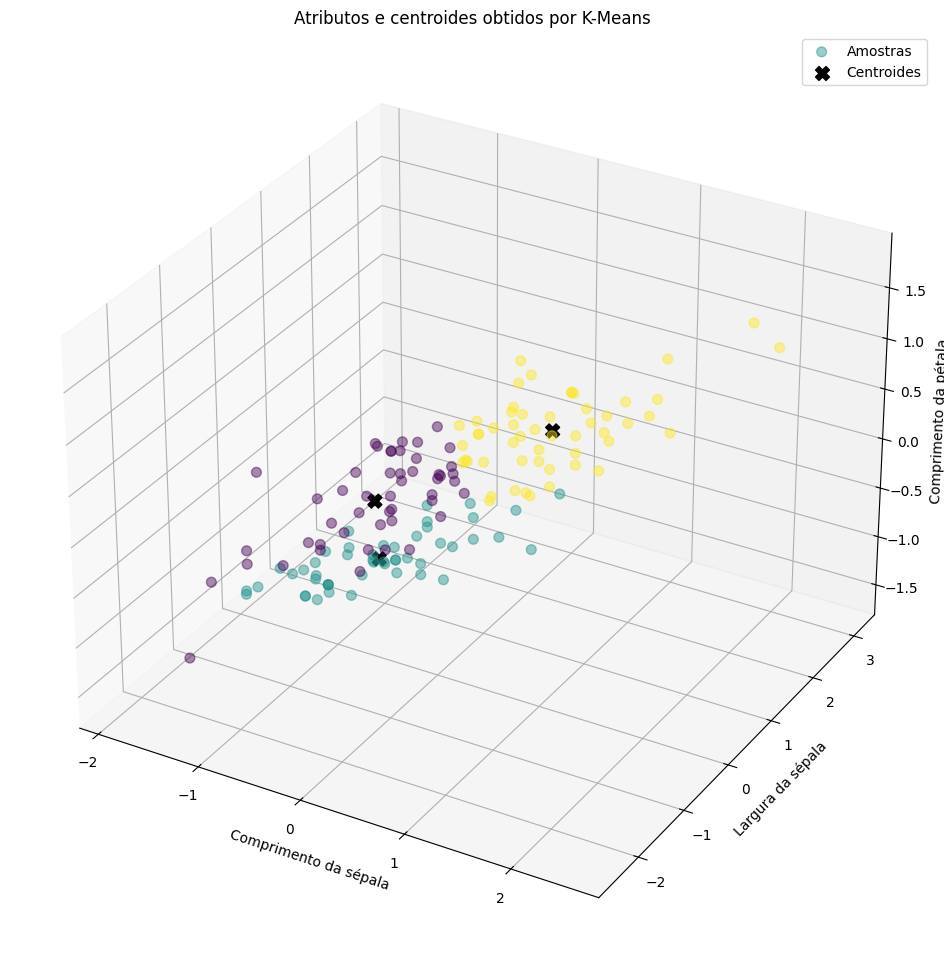

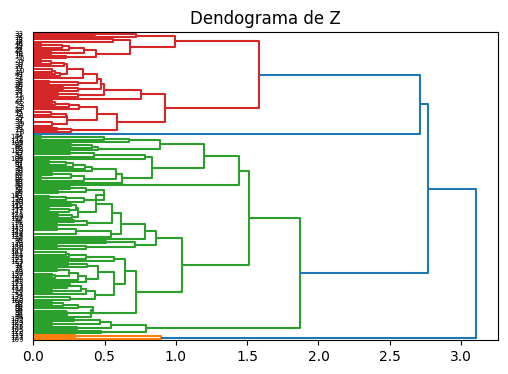

In [54]:
## -- Seu código começa AQUI -- ##

# Item 1 -----------------------------------------------------------------------

# Selecionando as colunas requeridas (comprimento da sépala, largura da sépala,
# comprimento da pétala)
X_iris_cols = X_iris[['sepal length', 'sepal width', 'petal length']]

# Realizando o pré-processamento dos dados com o método StandardScaler
scaler = StandardScaler()  # Instanciando um objeto do StandardScaler
X_iris_std = scaler.fit_transform(X_iris_cols)  # Aplicando StandardScaler

# Aplicando o método K-Means
kmeans = KMeans(n_clusters=3, random_state=0).fit(X_iris_std)

# Obtendo os resultados
classe_de_cada_amostra = kmeans.labels_
centroides = kmeans.cluster_centers_

# Visualizando os resultados
print(f'Classe de cada amostra: \n{classe_de_cada_amostra}')
print(f'Centroides: \n{centroides}\n\n')

# Item 2 -----------------------------------------------------------------------

# Criando a figura e dizendo que será 3d
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(projection='3d')

# Plotando o espaço tridimensional com os atributos, utilizando scatter3D
ax.scatter3D(X_iris_std[:, 0], X_iris_std[:, 1], X_iris_std[:, 2],
             c=classe_de_cada_amostra, s=50, alpha=0.45, label='Amostras')

# Plotando os centroides calculados
ax.scatter3D(centroides[:, 0], centroides[:, 1], centroides[:, 2], c='black',
             marker='X', s=100, alpha=1.0, label='Centroides')

# Colocando legenda, título do gráfico e dos eixos
plt.legend()
plt.title('Atributos e centroides obtidos por K-Means')
ax.set_xlabel('Comprimento da sépala')
ax.set_ylabel('Largura da sépala')
ax.set_zlabel('Comprimento da pétala')
plt.show()

# Item 3 -----------------------------------------------------------------------

# Obtendo a Matriz de Distância dos dados padronizados (aqueles após a operação
# do StandardScaler)
D = pdist(X_iris_std)

# Item 4 -----------------------------------------------------------------------

# Definindo as ligações para agrupamento utilizando a Ligação Centróide
Z = linkage(D, 'centroid')

# Item 5 -----------------------------------------------------------------------

# Plotando o Dendrograma de Z
plt.figure(figsize=(6, 4))

H = dendrogram(Z, labels=X_iris.index, orientation='right')
plt.title('Dendograma de Z')
plt.show()

# Significado dos ramos do dendograma:
#
# Avançando no dendograma da esquerda para a direita, as amostras começam a ser
# agrupadas em clusters. Cada ramo é responsável por unir dois clusters. À medida
# que as amostras são agrupadas, a distância entre seus centroides vai aumentando,
# já que os grupos estão se diferenciando. Para uma distância de 2, por exemplo,
# pelo dendograma apresentado, teríamos 4 clusters distintos, enquanto que para
# uma distância de aproximadamente 2.7, teríamos 3, por exemplo.

## -- Seu código termina AQUI -- ##

## -- COMENTÁRIOS -- ##

## 4) Modelos Classificação

Nota: 3.5

Agora com base nos dois conjuntos de dados, **Iris** e **Doencas Cardiacas** vamos utilizar os classificadores (KNN, RandomForest e XGBoost) e a métrica de accuracia para ver a perfomance. Utilize um o StandardScaler como método de scaling dos aos e print os valores de acuracia para cada modelo.

Fiquem a vontade para ler a documentação dos classificadores, todas as funções estão explicadas e com exemplos!

Obs: não precisa se preocupar com a accuracia e nem com a divisao de treino/teste, será abordado nas próximas aulas, abaixo tem os exemplos dos codigos para realizar a divisão e o calculo de accuracia

In [55]:
# a divisao de treino/teste
from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# X_train.shape, X_test.shape, y_train.shape, y_test.shape

Treine os modelos RandomForest, KNN e XGBoost

In [56]:
# para instalar o XGBoost
!pip install xgboost

In [57]:
# importa os classificadores
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# para treinar os modelos
# model_XX = XXClassifier.fit(X_train, y_train)


In [58]:
## -- Seu código começa AQUI -- ##

# Normalizando os conjuntos de dados Iris e Heart Disease com StandardScaler
scaler = StandardScaler()                            # Instanciando objeto do StandardScaler
X_iris_std = scaler.fit_transform(X_iris)            # Aplicando em X_iris
X_heart_std = scaler.fit_transform(X_heart)          # Aplicando em X_heart

# Realizando a divisão de treino/teste para ambos os datasets
X_iris_train, X_iris_test, y_iris_train, y_iris_test = train_test_split(X_iris_std, y_iris_encoded, test_size=0.3, random_state=42)
X_heart_train, X_heart_test, y_heart_train, y_heart_test = train_test_split(X_heart_std, y_heart, test_size=0.3, random_state=42)

# Convertendo y_heart_train e y_heart_test para arrays para evitar problemas de indexação
y_heart_train = np.array(y_heart_train)
y_heart_test = np.array(y_heart_test)

# Removendo linhas com valores NaN tanto de X_heart_train quanto de y_heart_train usando uma máscara booleana
valid_train_idx = ~np.isnan(X_heart_train).any(axis=1)  # Índices válidos onde não há NaN em X_heart_train
X_heart_train = X_heart_train[valid_train_idx]
y_heart_train = y_heart_train[valid_train_idx]

# Removendo linhas com valores NaN em X_heart_test e ajustando y_heart_test
valid_test_idx = ~np.isnan(X_heart_test).any(axis=1)  # Índices válidos onde não há NaN em X_heart_test
X_heart_test = X_heart_test[valid_test_idx]
y_heart_test = y_heart_test[valid_test_idx]

# Treinando os modelos com cada um dos classificadores

# Iris dataset
model_rf = RandomForestClassifier().fit(X_iris_train, y_iris_train)          # RandomForestClassifier
model_knn = KNeighborsClassifier().fit(X_iris_train, y_iris_train)           # KNeighborsClassifier
model_xgb = XGBClassifier().fit(X_iris_train, y_iris_train)                  # XGBClassifier

# Heart Disease dataset
model_rf_heart = RandomForestClassifier().fit(X_heart_train, y_heart_train)  # RandomForestClassifier
model_knn_heart = KNeighborsClassifier().fit(X_heart_train, y_heart_train)   # KNeighborsClassifier
model_xgb_heart = XGBClassifier().fit(X_heart_train, y_heart_train)          # XGBClassifier

## -- Seu código termina AQUI -- ##

## -- COMENTÁRIOS -- ##

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [59]:
# para calcular a acuracia
from sklearn.metrics import accuracy_score

# predict retorna a classe já predita, 1, 0 etc.
# y_prob = model.predict(X_test)

# verificar a acuracia
# accuracy_score(y_test,y_prob)

# probabilidade das classes, retorna a probabilidade de ser uma classe ou outra, por exemplo 0.7 e 0.3.
# y_prob = model.predict_proba(X_test)

# se usar o predict_proba precisamos arredondar para 1 ou 0.
# accuracy_score(y_test,y_prob[:,1].round())

In [60]:
## -- Seu código começa AQUI -- ##

# Determinando a acurácia de cada classificador

# ----------------------------- Para o Iris dataset
y_prob_iris_rf = model_rf.predict(X_iris_test)   # y_prob = model.predict(X_test)
y_prob_iris_knn = model_knn.predict(X_iris_test)
y_prob_iris_xgb = model_xgb.predict(X_iris_test)

# ----------------------------- Para o Heart Disease dataset
y_prob_heart_rf = model_rf_heart.predict(X_heart_test)   # accuracy_score(y_test,y_prob)
y_prob_heart_knn = model_knn_heart.predict(X_heart_test)
y_prob_heart_xgb = model_xgb_heart.predict(X_heart_test)

# Printando os valores de acurácia
print('Valores de acurácia para os três classificadores, no caso do Iris dataset: \n')
print(f'RandomForestClassifier: {accuracy_score(y_iris_test, y_prob_iris_rf)}')
print(f'KNeighborsClassifier: {accuracy_score(y_iris_test, y_prob_iris_knn)}')
print(f'XGBClassifier: {accuracy_score(y_iris_test, y_prob_iris_xgb)}\n')

print('Valores de acurácia para os três classificadores, no caso do Heart Disease dataset: \n')
print(f'RandomForestClassifier: {accuracy_score(y_heart_test, y_prob_heart_rf)}')
print(f'KNeighborsClassifier: {accuracy_score(y_heart_test, y_prob_heart_knn)}')
print(f'XGBClassifier: {accuracy_score(y_heart_test, y_prob_heart_xgb)}')

## -- Seu código termina AQUI -- ##

## -- COMENTÁRIOS -- ##

Valores de acurácia para os três classificadores, no caso do Iris dataset: 

RandomForestClassifier: 1.0
KNeighborsClassifier: 1.0
XGBClassifier: 1.0

Valores de acurácia para os três classificadores, no caso do Heart Disease dataset: 

RandomForestClassifier: 0.5056179775280899
KNeighborsClassifier: 0.5617977528089888
XGBClassifier: 0.5056179775280899


Agora refaça os treinamentos nos conjuntos e dados **sem utilizar nenhuma tecnica de normalização**, deixa os dados originais (apenas transformados em numericos sem usar MinMaxScaler,StandardScaler ou RobustScaler).

Quais modelos tiveram alteração na acuracia?

In [61]:
## -- Seu código começa AQUI -- ##

# Realizando a divisão de treino/teste para ambos os datasets SEM NORMALIZAÇÃO
X_iris_train, X_iris_test, y_iris_train, y_iris_test = train_test_split(X_iris, y_iris_encoded, test_size=0.3, random_state=42)
X_heart_train, X_heart_test, y_heart_train, y_heart_test = train_test_split(X_heart, y_heart, test_size=0.3, random_state=42)

# Convertendo y_heart_train e y_heart_test para arrays para evitar problemas de indexação
y_heart_train = np.array(y_heart_train)
y_heart_test = np.array(y_heart_test)

# Removendo linhas com valores NaN tanto de X_heart_train quanto de y_heart_train usando uma máscara booleana
valid_train_idx = ~np.isnan(X_heart_train).any(axis=1)  # Índices válidos onde não há NaN em X_heart_train
X_heart_train = X_heart_train[valid_train_idx]
y_heart_train = y_heart_train[valid_train_idx]

# Removendo linhas com valores NaN em X_heart_test e ajustando y_heart_test
valid_test_idx = ~np.isnan(X_heart_test).any(axis=1)  # Índices válidos onde não há NaN em X_heart_test
X_heart_test = X_heart_test[valid_test_idx]
y_heart_test = y_heart_test[valid_test_idx]

# Treinando os modelos com cada um dos classificadores

# Iris dataset
model_rf = RandomForestClassifier().fit(X_iris_train, y_iris_train)          # RandomForestClassifier
model_knn = KNeighborsClassifier().fit(X_iris_train, y_iris_train)           # KNeighborsClassifier
model_xgb = XGBClassifier().fit(X_iris_train, y_iris_train)                  # XGBClassifier

# Heart Disease dataset
model_rf_heart = RandomForestClassifier().fit(X_heart_train, y_heart_train)  # RandomForestClassifier
model_knn_heart = KNeighborsClassifier().fit(X_heart_train, y_heart_train)   # KNeighborsClassifier
model_xgb_heart = XGBClassifier().fit(X_heart_train, y_heart_train)          # XGBClassifier

# Determinando a acurácia de cada classificador

# ----------------------------- Para o Iris dataset
y_prob_iris_rf = model_rf.predict(X_iris_test)   # y_prob = model.predict(X_test)
y_prob_iris_knn = model_knn.predict(X_iris_test)
y_prob_iris_xgb = model_xgb.predict(X_iris_test)

# ----------------------------- Para o Heart Disease dataset
y_prob_heart_rf = model_rf_heart.predict(X_heart_test)   # accuracy_score(y_test,y_prob)
y_prob_heart_knn = model_knn_heart.predict(X_heart_test)
y_prob_heart_xgb = model_xgb_heart.predict(X_heart_test)

# Printando os valores de acurácia
print('Valores de acurácia para os três classificadores, no caso do Iris dataset: \n')
print(f'RandomForestClassifier: {accuracy_score(y_iris_test, y_prob_iris_rf)}')
print(f'KNeighborsClassifier: {accuracy_score(y_iris_test, y_prob_iris_knn)}')
print(f'XGBClassifier: {accuracy_score(y_iris_test, y_prob_iris_xgb)}\n')

print('Valores de acurácia para os três classificadores, no caso do Heart Disease dataset: \n')
print(f'RandomForestClassifier: {accuracy_score(y_heart_test, y_prob_heart_rf)}')
print(f'KNeighborsClassifier: {accuracy_score(y_heart_test, y_prob_heart_knn)}')
print(f'XGBClassifier: {accuracy_score(y_heart_test, y_prob_heart_xgb)}')

## -- Seu código termina AQUI -- ##

## -- COMENTÁRIOS -- ##

# Conforme evidenciado pelos prints, os modelos 'model_rf_heart' e 'model_knn_heart',
# ou seja, realizados com os classificadores RandomForestClassifier e KNeighborsClassifier,
# para o caso do Heart Disease dataset, tiveram alteração na acurácia.

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Valores de acurácia para os três classificadores, no caso do Iris dataset: 

RandomForestClassifier: 1.0
KNeighborsClassifier: 1.0
XGBClassifier: 1.0

Valores de acurácia para os três classificadores, no caso do Heart Disease dataset: 

RandomForestClassifier: 0.550561797752809
KNeighborsClassifier: 0.5056179775280899
XGBClassifier: 0.5056179775280899
